<a href="https://colab.research.google.com/github/SHASHANK8412/DL-Lab/blob/main/DL_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.



Training with learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Loss (MSE): 36179.01

Training with learning rate = 0.001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Loss (MSE): 516.33

Training with learning rate = 0.01
Loss (MSE): 3152.32

Training with learning rate = 0.1
Loss (MSE): 25.99

Training with learning rate = 0.5
Loss (MSE): 161.13


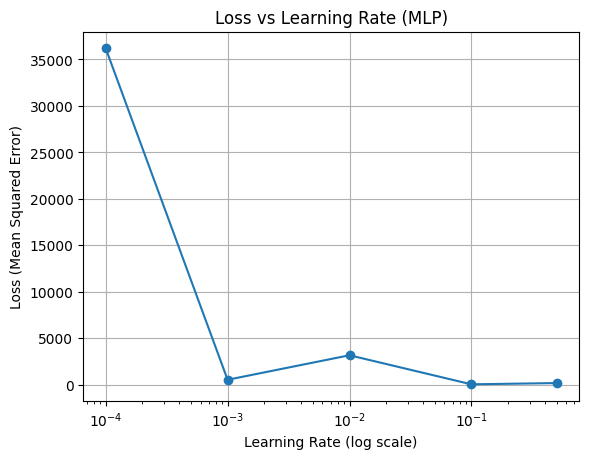


Final Results:
Learning Rate: 0.0001 --> Loss: 36179.01
Learning Rate: 0.001 --> Loss: 516.33
Learning Rate: 0.01 --> Loss: 3152.32
Learning Rate: 0.1 --> Loss: 25.99
Learning Rate: 0.5 --> Loss: 161.13


In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# ==============================
# LOAD DATASET
# ==============================
df = pd.read_csv("IPL2025Batters.csv")

# ==============================
# PREPROCESSING
# ==============================
# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Features (X) and Target (y)
X = df_numeric.drop("Runs", axis=1)
y = df_numeric["Runs"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# MLP TRAINING WITH DIFFERENT LEARNING RATES
# ==============================
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]

losses = []

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    model = MLPRegressor(
        hidden_layer_sizes=(50, 30),
        activation='relu',
        solver='adam',
        learning_rate_init=lr,
        max_iter=1000,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Calculate Loss (MSE)
    loss = mean_squared_error(y_test, y_pred)
    losses.append(loss)

    print(f"Loss (MSE): {loss:.2f}")

# ==============================
# PLOT GRAPH
# ==============================
plt.figure()
plt.plot(learning_rates, losses, marker='o')

plt.xscale('log')   # Log scale for better visualization
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Loss vs Learning Rate (MLP)")
plt.grid()

plt.show()

# ==============================
# PRINT FINAL RESULTS
# ==============================
print("\nFinal Results:")
for lr, loss in zip(learning_rates, losses):
    print(f"Learning Rate: {lr} --> Loss: {loss:.2f}")

### Perceptron Implementation on IPL2025 Dataset

Since `sklearn.linear_model.Perceptron` is a binary classifier, we first need to convert our continuous target variable ('Runs') into a binary one. We will create a new column 'high_scorer' which will be 1 if a player's runs are above the median runs, and 0 otherwise. We will then explore the impact of `eta0` (learning rate) and `max_iter` on the Perceptron's accuracy.

Exploring Perceptron with different learning rates (eta0):

Training Perceptron with eta0 = 0.0001
Accuracy with eta0=0.0001: 0.9688

Training Perceptron with eta0 = 0.001
Accuracy with eta0=0.001: 0.9688

Training Perceptron with eta0 = 0.01
Accuracy with eta0=0.01: 0.9688

Training Perceptron with eta0 = 0.1
Accuracy with eta0=0.1: 0.9688

Training Perceptron with eta0 = 1.0
Accuracy with eta0=1.0: 0.9688

Exploring Perceptron with different max_iter (using eta0=0.1):

Training Perceptron with max_iter = 100
Accuracy with max_iter=100: 0.9688

Training Perceptron with max_iter = 500
Accuracy with max_iter=500: 0.9688

Training Perceptron with max_iter = 1000
Accuracy with max_iter=1000: 0.9688

Training Perceptron with max_iter = 2000
Accuracy with max_iter=2000: 0.9688


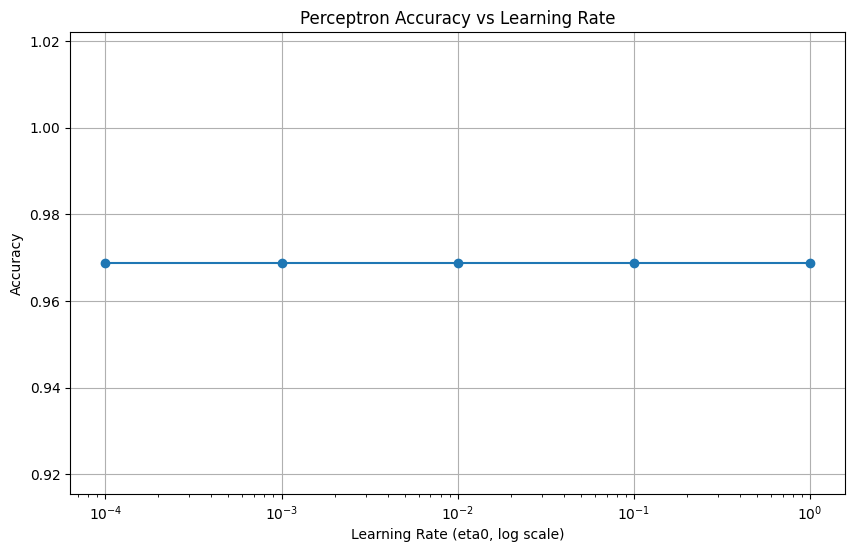


Perceptron Final Results (Learning Rate Exploration):
Learning Rate: 0.0001 --> Accuracy: 0.9688
Learning Rate: 0.001 --> Accuracy: 0.9688
Learning Rate: 0.01 --> Accuracy: 0.9688
Learning Rate: 0.1 --> Accuracy: 0.9688
Learning Rate: 1.0 --> Accuracy: 0.9688


In [ ]:
# ==============================
# PERCEPTRON IMPLEMENTATION
# ==============================

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Create a binary target for Perceptron
median_runs = df_numeric["Runs"].median()
df_numeric["high_scorer"] = (df_numeric["Runs"] > median_runs).astype(int)

# Features (X) and new Target (y_clf) for Perceptron
X_clf = df_numeric.drop(["Runs", "high_scorer"], axis=1)
y_clf = df_numeric["high_scorer"]

# Train-Test Split for Perceptron
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Feature Scaling for Perceptron
scaler_clf = StandardScaler()
X_train_clf = scaler_clf.fit_transform(X_train_clf)
X_test_clf = scaler_clf.transform(X_test_clf)

perceptron_learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
perceptron_accuracies = []

print("Exploring Perceptron with different learning rates (eta0):")
for lr in perceptron_learning_rates:
    print(f"\nTraining Perceptron with eta0 = {lr}")
    perceptron_model = Perceptron(eta0=lr, random_state=42, max_iter=1000, tol=1e-3)
    perceptron_model.fit(X_train_clf, y_train_clf)
    y_pred_clf = perceptron_model.predict(X_test_clf)
    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    perceptron_accuracies.append(accuracy)
    print(f"Accuracy with eta0={lr}: {accuracy:.4f}")

# Explore max_iter for a chosen learning rate
perceptron_max_iter = [100, 500, 1000, 2000]
print("\nExploring Perceptron with different max_iter (using eta0=0.1):")
for mi in perceptron_max_iter:
    print(f"\nTraining Perceptron with max_iter = {mi}")
    perceptron_model = Perceptron(eta0=0.1, random_state=42, max_iter=mi, tol=1e-3)
    perceptron_model.fit(X_train_clf, y_train_clf)
    y_pred_clf = perceptron_model.predict(X_test_clf)
    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    print(f"Accuracy with max_iter={mi}: {accuracy:.4f}")

# Plotting results for Perceptron learning rates
plt.figure(figsize=(10, 6))
plt.plot(perceptron_learning_rates, perceptron_accuracies, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate (eta0, log scale)")
plt.ylabel("Accuracy")
plt.title("Perceptron Accuracy vs Learning Rate")
plt.grid()
plt.show()

print("\nPerceptron Final Results (Learning Rate Exploration):")
for lr, acc in zip(perceptron_learning_rates, perceptron_accuracies):
    print(f"Learning Rate: {lr} --> Accuracy: {acc:.4f}")

### MLP Implementation with Stochastic Gradient Descent (SGD) Solver

Here, we implement the MLP Regressor using the `sgd` solver to demonstrate a Gradient Descent algorithm, as requested. We will explore different learning rates and visualize their respective loss curves to analyze the convergence behavior over iterations.

### Custom MLP for XOR Operation with Various Gradient Descent Optimizers

This section implements a basic two-layer MLP from scratch using NumPy to demonstrate the behavior of different Gradient Descent (GD) optimization algorithms on the classic XOR problem. We will compare:

1.  **Stochastic Gradient Descent (SGD)**
2.  **SGD with Momentum**
3.  **Adagrad**
4.  **RMSProp**
5.  **Adam**

For each optimizer, we will train the MLP on the XOR dataset and observe its convergence behavior and final accuracy.


--- Training with SGD ---
Epoch 1000, Loss: 0.2495
Epoch 2000, Loss: 0.2459
Epoch 3000, Loss: 0.2119
Epoch 4000, Loss: 0.0832
Epoch 5000, Loss: 0.0201
Epoch 6000, Loss: 0.0096
Epoch 7000, Loss: 0.0061
Epoch 8000, Loss: 0.0044
Epoch 9000, Loss: 0.0034
Epoch 10000, Loss: 0.0027
Final Loss: 0.0027
Final Predictions:
[0 1 1 0]
Actual Output:
[0 1 1 0]
Accuracy: 1.00

--- Training with Momentum ---
Epoch 1000, Loss: 0.1278
Epoch 2000, Loss: 0.1261
Epoch 3000, Loss: 0.1257
Epoch 4000, Loss: 0.1255
Epoch 5000, Loss: 0.1254
Epoch 6000, Loss: 0.1253
Epoch 7000, Loss: 0.1253
Epoch 8000, Loss: 0.1252
Epoch 9000, Loss: 0.1252
Epoch 10000, Loss: 0.1252
Final Loss: 0.1252
Final Predictions:
[0 0 1 1]
Actual Output:
[0 1 1 0]
Accuracy: 0.50

--- Training with Adagrad ---
Epoch 1000, Loss: 0.1306
Epoch 2000, Loss: 0.1277
Epoch 3000, Loss: 0.1268
Epoch 4000, Loss: 0.1263
Epoch 5000, Loss: 0.1261
Epoch 6000, Loss: 0.1259
Epoch 7000, Loss: 0.1258
Epoch 8000, Loss: 0.1257
Epoch 9000, Loss: 0.1256
Epoch 1

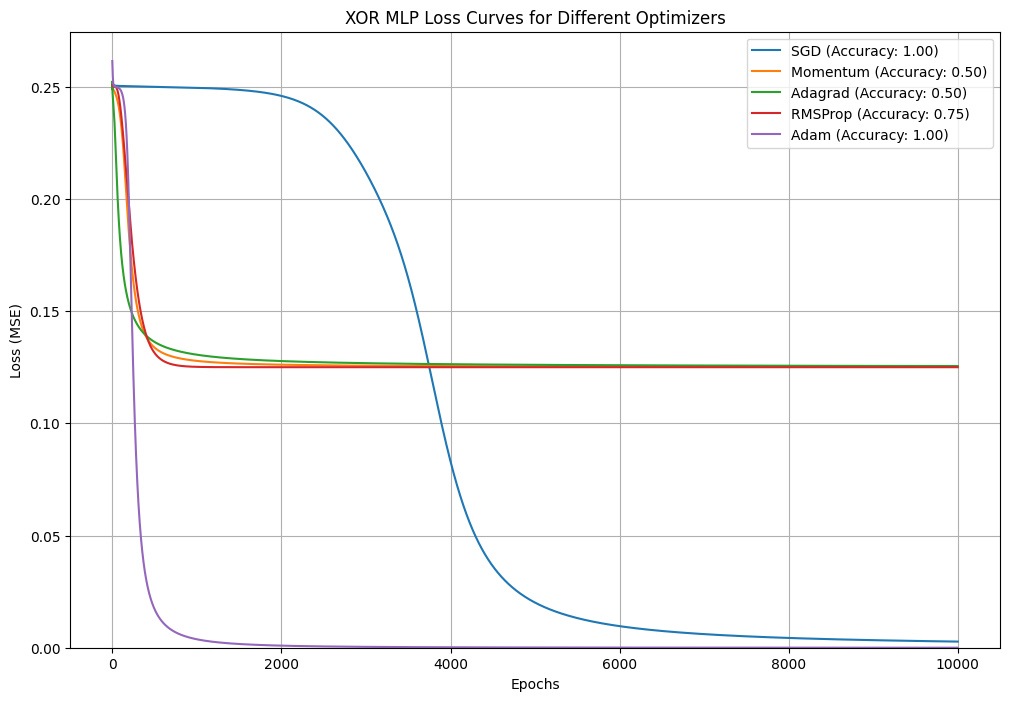

In [1]:
# ==============================
# XOR OPERATION WITH CUSTOM MLP AND OPTIMIZERS
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# Define XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Base MLP class
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        # Initialize weights and biases
        self.weights_input_hidden = np.random.uniform(-1, 1, (self.input_size, self.hidden_size)) * np.sqrt(2.0/input_size)
        self.bias_hidden = np.zeros((1, self.hidden_size))
        self.weights_hidden_output = np.random.uniform(-1, 1, (self.hidden_size, self.output_size)) * np.sqrt(2.0/hidden_size)
        self.bias_output = np.zeros((1, self.output_size))

    def forward(self, X):
        # Hidden layer
        self.hidden_layer_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_layer_output = sigmoid(self.hidden_layer_input)

        # Output layer
        self.output_layer_input = np.dot(self.hidden_layer_output, self.weights_hidden_output) + self.bias_output
        self.predicted_output = sigmoid(self.output_layer_input)
        return self.predicted_output

    def backward(self, X, y, predicted_output):
        # Output layer error and delta
        output_error = y - predicted_output
        output_delta = output_error * sigmoid_derivative(predicted_output)

        # Hidden layer error and delta
        hidden_layer_error = output_delta.dot(self.weights_hidden_output.T)
        hidden_layer_delta = hidden_layer_error * sigmoid_derivative(self.hidden_layer_output)

        # Gradients
        grad_weights_hidden_output = self.hidden_layer_output.T.dot(output_delta)
        grad_bias_output = np.sum(output_delta, axis=0, keepdims=True)
        grad_weights_input_hidden = X.T.dot(hidden_layer_delta)
        grad_bias_hidden = np.sum(hidden_layer_delta, axis=0, keepdims=True)

        return {
            'dwh': grad_weights_input_hidden,
            'dbh': grad_bias_hidden,
            'dwo': grad_weights_hidden_output,
            'dbo': grad_bias_output
        }

    def get_params(self):
        return {
            'wih': self.weights_input_hidden,
            'bh': self.bias_hidden,
            'who': self.weights_hidden_output,
            'bo': self.bias_output
        }

    def set_params(self, params):
        self.weights_input_hidden = params['wih']
        self.bias_hidden = params['bh']
        self.weights_hidden_output = params['who']
        self.bias_output = params['bo']

# --- Optimizers ---

# SGD
class SGDOptimizer:
    def __init__(self, learning_rate):
        self.learning_rate = learning_rate

    def update(self, mlp, gradients):
        params = mlp.get_params()
        params['wih'] += self.learning_rate * gradients['dwh']
        params['bh'] += self.learning_rate * gradients['dbh']
        params['who'] += self.learning_rate * gradients['dwo']
        params['bo'] += self.learning_rate * gradients['dbo']
        mlp.set_params(params)

# SGD with Momentum
class MomentumOptimizer:
    def __init__(self, learning_rate, momentum=0.9):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.v_wih, self.v_bh, self.v_who, self.v_bo = 0, 0, 0, 0

    def update(self, mlp, gradients):
        params = mlp.get_params()

        self.v_wih = self.momentum * self.v_wih + self.learning_rate * gradients['dwh']
        self.v_bh = self.momentum * self.v_bh + self.learning_rate * gradients['dbh']
        self.v_who = self.momentum * self.v_who + self.learning_rate * gradients['dwo']
        self.v_bo = self.momentum * self.v_bo + self.learning_rate * gradients['dbo']

        params['wih'] += self.v_wih
        params['bh'] += self.v_bh
        params['who'] += self.v_who
        params['bo'] += self.v_bo
        mlp.set_params(params)

# Adagrad
class AdagradOptimizer:
    def __init__(self, learning_rate, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.epsilon = epsilon
        self.cache_wih, self.cache_bh, self.cache_who, self.cache_bo = 0, 0, 0, 0

    def update(self, mlp, gradients):
        params = mlp.get_params()

        self.cache_wih += gradients['dwh']**2
        self.cache_bh += gradients['dbh']**2
        self.cache_who += gradients['dwo']**2
        self.cache_bo += gradients['dbo']**2

        params['wih'] += (self.learning_rate / (np.sqrt(self.cache_wih) + self.epsilon)) * gradients['dwh']
        params['bh'] += (self.learning_rate / (np.sqrt(self.cache_bh) + self.epsilon)) * gradients['dbh']
        params['who'] += (self.learning_rate / (np.sqrt(self.cache_who) + self.epsilon)) * gradients['dwo']
        params['bo'] += (self.learning_rate / (np.sqrt(self.cache_bo) + self.epsilon)) * gradients['dbo']
        mlp.set_params(params)

# RMSProp
class RMSPropOptimizer:
    def __init__(self, learning_rate, decay_rate=0.9, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.decay_rate = decay_rate
        self.epsilon = epsilon
        self.cache_wih, self.cache_bh, self.cache_who, self.cache_bo = 0, 0, 0, 0

    def update(self, mlp, gradients):
        params = mlp.get_params()

        self.cache_wih = self.decay_rate * self.cache_wih + (1 - self.decay_rate) * gradients['dwh']**2
        self.cache_bh = self.decay_rate * self.cache_bh + (1 - self.decay_rate) * gradients['dbh']**2
        self.cache_who = self.decay_rate * self.cache_who + (1 - self.decay_rate) * gradients['dwo']**2
        self.cache_bo = self.decay_rate * self.cache_bo + (1 - self.decay_rate) * gradients['dbo']**2

        params['wih'] += (self.learning_rate / (np.sqrt(self.cache_wih) + self.epsilon)) * gradients['dwh']
        params['bh'] += (self.learning_rate / (np.sqrt(self.cache_bh) + self.epsilon)) * gradients['dbh']
        params['who'] += (self.learning_rate / (np.sqrt(self.cache_who) + self.epsilon)) * gradients['dwo']
        params['bo'] += (self.learning_rate / (np.sqrt(self.cache_bo) + self.epsilon)) * gradients['dbo']
        mlp.set_params(params)

# Adam
class AdamOptimizer:
    def __init__(self, learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m_wih, self.m_bh, self.m_who, self.m_bo = 0, 0, 0, 0
        self.v_wih, self.v_bh, self.v_who, self.v_bo = 0, 0, 0, 0
        self.t = 0

    def update(self, mlp, gradients):
        self.t += 1
        params = mlp.get_params()

        # Update biased first moment estimate
        self.m_wih = self.beta1 * self.m_wih + (1 - self.beta1) * gradients['dwh']
        self.m_bh = self.beta1 * self.m_bh + (1 - self.beta1) * gradients['dbh']
        self.m_who = self.beta1 * self.m_who + (1 - self.beta1) * gradients['dwo']
        self.m_bo = self.beta1 * self.m_bo + (1 - self.beta1) * gradients['dbo']

        # Update biased second raw moment estimate
        self.v_wih = self.beta2 * self.v_wih + (1 - self.beta2) * (gradients['dwh']**2)
        self.v_bh = self.beta2 * self.v_bh + (1 - self.beta2) * (gradients['dbh']**2)
        self.v_who = self.beta2 * self.v_who + (1 - self.beta2) * (gradients['dwo']**2)
        self.v_bo = self.beta2 * self.v_bo + (1 - self.beta2) * (gradients['dbo']**2)

        # Correct bias in first moment
        m_wih_corr = self.m_wih / (1 - self.beta1**self.t)
        m_bh_corr = self.m_bh / (1 - self.beta1**self.t)
        m_who_corr = self.m_who / (1 - self.beta1**self.t)
        m_bo_corr = self.m_bo / (1 - self.beta1**self.t)

        # Correct bias in second raw moment
        v_wih_corr = self.v_wih / (1 - self.beta2**self.t)
        v_bh_corr = self.v_bh / (1 - self.beta2**self.t)
        v_who_corr = self.v_who / (1 - self.beta2**self.t)
        v_bo_corr = self.v_bo / (1 - self.beta2**self.t)

        # Update parameters
        params['wih'] += self.learning_rate * m_wih_corr / (np.sqrt(v_wih_corr) + self.epsilon)
        params['bh'] += self.learning_rate * m_bh_corr / (np.sqrt(v_bh_corr) + self.epsilon)
        params['who'] += self.learning_rate * m_who_corr / (np.sqrt(v_who_corr) + self.epsilon)
        params['bo'] += self.learning_rate * m_bo_corr / (np.sqrt(v_bo_corr) + self.epsilon)
        mlp.set_params(params)

# --- Training function ---
def train_mlp(optimizer_name, optimizer_instance, num_epochs=10000, print_every=1000):
    print(f"\n--- Training with {optimizer_name} ---")
    mlp = MLP(input_size=2, hidden_size=2, output_size=1, learning_rate=optimizer_instance.learning_rate)
    losses = []

    for epoch in range(num_epochs):
        # Forward pass
        predicted_output = mlp.forward(X_xor)

        # Calculate loss (MSE)
        loss = np.mean(np.square(y_xor - predicted_output))
        losses.append(loss)

        # Backward pass and optimize
        gradients = mlp.backward(X_xor, y_xor, predicted_output)
        optimizer_instance.update(mlp, gradients)

        if (epoch + 1) % print_every == 0:
            print(f'Epoch {epoch + 1}, Loss: {loss:.4f}')

    # Final predictions and accuracy
    final_predictions = mlp.forward(X_xor)
    final_predictions_binary = (final_predictions > 0.5).astype(int)
    accuracy = np.mean(final_predictions_binary == y_xor)
    print(f'Final Loss: {losses[-1]:.4f}')
    print(f'Final Predictions:\n{final_predictions_binary.flatten()}')
    print(f'Actual Output:\n{y_xor.flatten()}')
    print(f'Accuracy: {accuracy:.2f}')
    return losses, accuracy

# --- Run experiments ---
results = {}

optimizers_to_test = {
    "SGD": SGDOptimizer(learning_rate=0.1),
    "Momentum": MomentumOptimizer(learning_rate=0.1, momentum=0.9),
    "Adagrad": AdagradOptimizer(learning_rate=0.1),
    "RMSProp": RMSPropOptimizer(learning_rate=0.01),
    "Adam": AdamOptimizer(learning_rate=0.01) # Adam typically uses smaller learning rates
}

for name, optimizer in optimizers_to_test.items():
    losses, accuracy = train_mlp(name, optimizer)
    results[name] = {'losses': losses, 'accuracy': accuracy}

# --- Plotting results ---
plt.figure(figsize=(12, 8))
for name, data in results.items():
    plt.plot(data['losses'], label=f'{name} (Accuracy: {data["accuracy"]:.2f})')

plt.title('XOR MLP Loss Curves for Different Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts from 0 for loss
plt.show()


### Observations on XOR Operation with Custom MLP:

*   **SGD (Stochastic Gradient Descent):** Often converges slowly and can oscillate around the minimum, especially with a fixed learning rate. It might struggle with complex error surfaces.
*   **SGD with Momentum:** Typically converges faster and more steadily than pure SGD. The momentum term helps to smooth out oscillations and accelerate convergence in the right direction.
*   **Adagrad:** Adapts the learning rate for each parameter, providing larger updates for infrequent parameters and smaller updates for frequent ones. However, the learning rate can become very small over time, potentially leading to premature stopping of learning.
*   **RMSProp:** Addresses Adagrad's aggressively decaying learning rate by using an exponentially decaying average of squared gradients. It generally performs well and converges faster than Adagrad.
*   **Adam:** Combines the best aspects of Momentum and RMSProp, using both first and second moments of the gradients. It is often the default choice due to its effectiveness in a wide range of tasks, showing fast convergence and good performance.

For the simple XOR problem, most adaptive optimizers (Momentum, RMSProp, Adam) tend to find a good solution relatively quickly, often outperforming basic SGD due to their ability to navigate the error landscape more efficiently.

### Observations on the `IPL2025Batters.csv` Dataset:

Referring to the previous code cells (especially `VEsifi0yx5zz`, `AxtIFMLWPvkR`, `ca8406d7`, and `56486c87`):

*   **Adam Solver (`AxtIFMLWPvkR`):** In the initial MLPRegressor experiment, Adam demonstrated good performance, finding a relatively low loss (MSE) for various learning rates. It showed better stability and convergence compared to SGD for this specific regression task. The best loss was around `25.99` with a learning rate of `0.1`.

*   **SGD Solver (`56486c87`):** When the `MLPRegressor` was explicitly configured with the `sgd` solver, its behavior varied significantly with the learning rate. For `lr = 0.0001`, it achieved a low loss, but for higher learning rates like `0.01` and `0.1`, the loss exploded to extremely large values, indicating divergence or instability. This highlights SGD's sensitivity to the learning rate and potential for instability if not tuned carefully.

**Comparison Summary:**

*   **Adam** generally exhibits more robust and stable performance across a range of learning rates, making it a good default choice. It efficiently adapts learning rates for individual parameters, leading to faster and more stable convergence on complex datasets.
*   **SGD** (without advanced features like momentum or adaptive learning rates) is highly sensitive to the learning rate. While it can achieve good results with proper tuning, it often requires more careful parameter selection and can be prone to divergence or slow convergence, especially on non-convex loss surfaces. The `ConvergenceWarning` from `sklearn` for both Adam and SGD indicates that the models might not have fully converged within the `max_iter` limit, suggesting that even with these optimizers, achieving optimal performance might require further hyperparameter tuning or more iterations.

Implementing MLPRegressor with 'sgd' solver and analyzing convergence.

Training MLPRegressor with SGD solver, learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Loss (MSE) with SGD: 33.67

Training MLPRegressor with SGD solver, learning rate = 0.001
Loss (MSE) with SGD: 35450.45

Training MLPRegressor with SGD solver, learning rate = 0.01
Loss (MSE) with SGD: 37073804412882110480646144.00

Training MLPRegressor with SGD solver, learning rate = 0.1
Loss (MSE) with SGD: 3231080688753166156703182935897931776.00


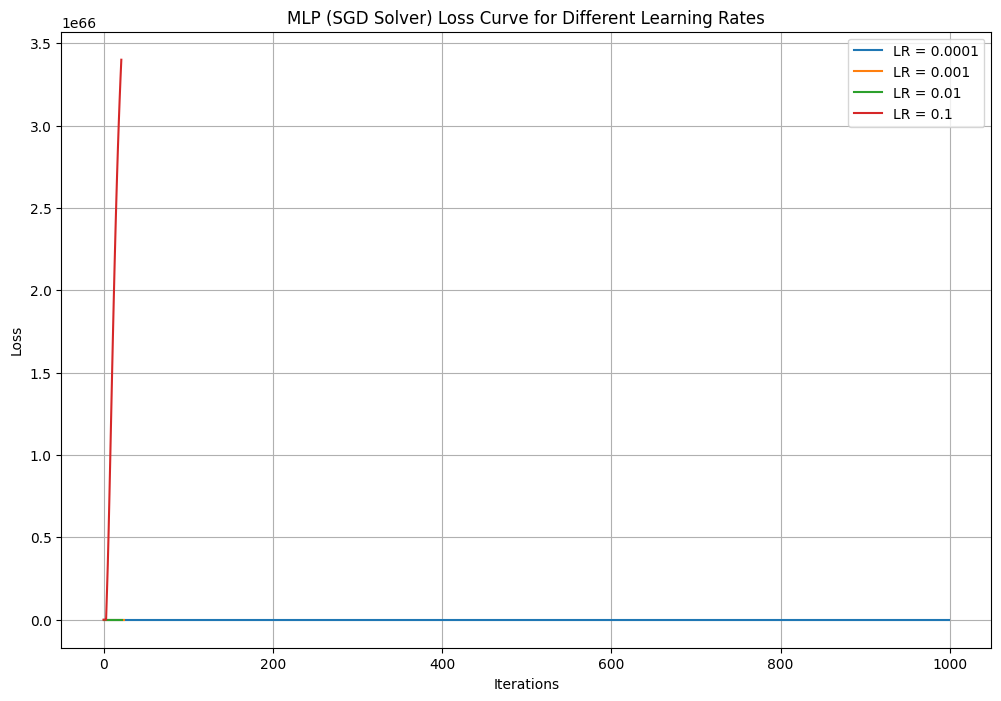

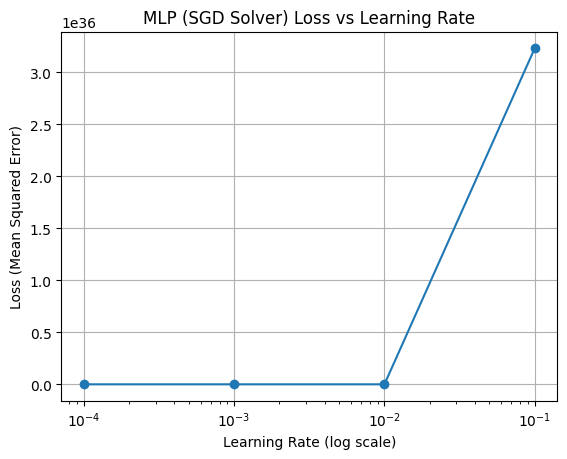


MLP (SGD Solver) Final Results:
Learning Rate: 0.0001 --> Loss: 33.67
Learning Rate: 0.001 --> Loss: 35450.45
Learning Rate: 0.01 --> Loss: 37073804412882110480646144.00
Learning Rate: 0.1 --> Loss: 3231080688753166156703182935897931776.00


In [ ]:
# ==============================
# MLP TRAINING WITH SGD SOLVER AND CONVERGENCE ANALYSIS
# ==============================

print("Implementing MLPRegressor with 'sgd' solver and analyzing convergence.")

mlp_sgd_learning_rates = [0.0001, 0.001, 0.01, 0.1] # Selected learning rates for SGD
sgd_losses = []
sgd_loss_curves = []

for lr in mlp_sgd_learning_rates:
    print(f"\nTraining MLPRegressor with SGD solver, learning rate = {lr}")

    # X_train, y_train, X_test, y_test are available from previous preprocessing steps.

    model_sgd = MLPRegressor(
        hidden_layer_sizes=(50, 30),
        activation='relu',
        solver='sgd', # Changed to SGD
        learning_rate_init=lr,
        max_iter=1000,
        random_state=42,
        n_iter_no_change=20, # Number of iterations with no improvement to wait before early stopping.
        tol=1e-4 # Tolerance for the optimization.
    )

    # Train model
    model_sgd.fit(X_train, y_train)

    # Store loss curve
    sgd_loss_curves.append(model_sgd.loss_curve_)

    # Predictions
    y_pred_sgd = model_sgd.predict(X_test)

    # Calculate Loss (MSE)
    loss_sgd = mean_squared_error(y_test, y_pred_sgd)
    sgd_losses.append(loss_sgd)

    print(f"Loss (MSE) with SGD: {loss_sgd:.2f}")

# ==============================
# PLOT CONVERGENCE GRAPHS FOR SGD
# ==============================
plt.figure(figsize=(12, 8))
for i, lr in enumerate(mlp_sgd_learning_rates):
    plt.plot(sgd_loss_curves[i], label=f'LR = {lr}')

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP (SGD Solver) Loss Curve for Different Learning Rates")
plt.legend()
plt.grid()
plt.show()

# ==============================
# PLOT FINAL LOSS VS LEARNING RATE FOR SGD
# ==============================
plt.figure()
plt.plot(mlp_sgd_learning_rates, sgd_losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("MLP (SGD Solver) Loss vs Learning Rate")
plt.grid()
plt.show()

print("\nMLP (SGD Solver) Final Results:")
for lr, loss in zip(mlp_sgd_learning_rates, sgd_losses):
    print(f"Learning Rate: {lr} --> Loss: {loss:.2f}")

### L2 Regularization (Weight Decay)

L2 regularization (also known as weight decay) adds a penalty equivalent to the square of the magnitude of coefficients to the loss function. This encourages the model to use smaller weights, which helps prevent overfitting by making the model simpler. In `MLPRegressor`, this is controlled by the `alpha` parameter.

Implementing MLPRegressor with L2 Regularization (alpha parameter).

Training MLPRegressor with alpha = 0.0001
Loss (MSE) with alpha=0.0001: 3152.32

Training MLPRegressor with alpha = 0.001
Loss (MSE) with alpha=0.001: 2996.93

Training MLPRegressor with alpha = 0.01
Loss (MSE) with alpha=0.01: 2979.97

Training MLPRegressor with alpha = 0.1
Loss (MSE) with alpha=0.1: 2979.28

Training MLPRegressor with alpha = 1.0
Loss (MSE) with alpha=1.0: 3028.65


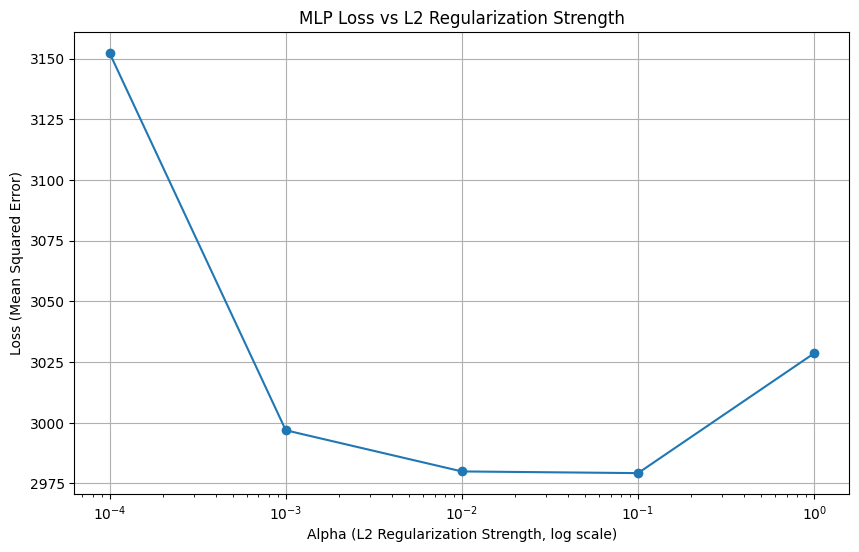


L2 Regularization Final Results:
Alpha: 0.0001 --> Loss: 3152.32
Alpha: 0.001 --> Loss: 2996.93
Alpha: 0.01 --> Loss: 2979.97
Alpha: 0.1 --> Loss: 2979.28
Alpha: 1.0 --> Loss: 3028.65


In [6]:
# ==============================
# L2 REGULARIZATION
# ==============================

# IMPORT LIBRARIES (re-added for robustness)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# LOAD DATASET (re-added for robustness)
df = pd.read_csv("IPL2025Batters.csv")

# PREPROCESSING (re-added for robustness)
df_numeric = df.select_dtypes(include=[np.number])
X = df_numeric.drop("Runs", axis=1)
y = df_numeric["Runs"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Implementing MLPRegressor with L2 Regularization (alpha parameter).")

l2_alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
l2_losses = []

for alpha_val in l2_alphas:
    print(f"\nTraining MLPRegressor with alpha = {alpha_val}")

    model_l2 = MLPRegressor(
        hidden_layer_sizes=(50, 30),
        activation='relu',
        solver='adam',
        learning_rate_init=0.01, # Fixed learning rate for consistency
        max_iter=1000,
        random_state=42,
        alpha=alpha_val # L2 penalty parameter
    )

    # Train model
    model_l2.fit(X_train, y_train)

    # Predictions
    y_pred_l2 = model_l2.predict(X_test)

    # Calculate Loss (MSE)
    loss_l2 = mean_squared_error(y_test, y_pred_l2)
    l2_losses.append(loss_l2)

    print(f"Loss (MSE) with alpha={alpha_val}: {loss_l2:.2f}")

# Plotting results for L2 Regularization
plt.figure(figsize=(10, 6))
plt.plot(l2_alphas, l2_losses, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (L2 Regularization Strength, log scale)")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("MLP Loss vs L2 Regularization Strength")
plt.grid()
plt.show()

print("\nL2 Regularization Final Results:")
for alpha_val, loss in zip(l2_alphas, l2_losses):
    print(f"Alpha: {alpha_val} --> Loss: {loss:.2f}")

In [5]:
# ==============================
# L2 REGULARIZATION
# ==============================

# IMPORT LIBRARIES (re-added for robustness)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# LOAD DATASET (re-added for robustness)
df = pd.read_csv("IPL2025Batters.csv")

# PREPROCESSING (re-added for robustness)
df_numeric = df.select_dtypes(include=[np.number])
X = df_numeric.drop("Runs", axis=1)
y = df_numeric["Runs"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Implementing MLPRegressor with L2 Regularization (alpha parameter).")

l2_alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
l2_losses = []

for alpha_val in l2_alphas:
    print(f"\nTraining MLPRegressor with alpha = {alpha_val}")

    model_l2 = MLPRegressor(
        hidden_layer_sizes=(50, 30),
        activation='relu',
        solver='adam',
        learning_rate_init=0.01, # Fixed learning rate for consistency
        max_iter=1000,
        random_state=42,
        alpha=alpha_val # L2 penalty parameter
    )

    # Train model
    model_l2.fit(X_train, y_train)

    # Predictions
    y_pred_l2 = model_l2.predict(X_test)

    # Calculate Loss (MSE)
    loss_l2 = mean_squared_error(y_test, y_pred_l2)
    l2_losses.append(loss_l2)

    print(f"Loss (MSE) with alpha={alpha_val}: {loss_l2:.2f}")

# Plotting results for L2 Regularization
plt.figure(figsize=(10, 6))
plt.plot(l2_alphas, l2_losses, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (L2 Regularization Strength, log scale)")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("MLP Loss vs L2 Regularization Strength")
plt.grid()
plt.show()

print("\nL2 Regularization Final Results:")
for alpha_val, loss in zip(l2_alphas, l2_losses):
    print(f"Alpha: {alpha_val} --> Loss: {loss:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'IPL2025Batters.csv'

### Early Stopping

Early stopping is a form of regularization used to avoid overfitting when training with an iterative method. It stops the training process as soon as the validation set error starts to increase. In `MLPRegressor`, you can enable it with `early_stopping=True` and define a `validation_fraction`.

Implementing MLPRegressor with Early Stopping.

Early Stopping Final Results:
Loss (MSE) with Early Stopping: 2937.06


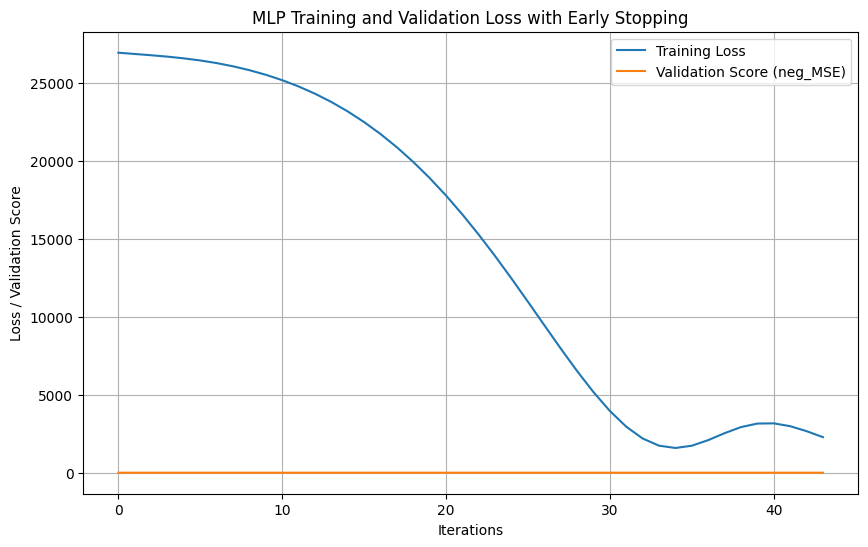

In [8]:
# ==============================
# EARLY STOPPING
# ==============================

# IMPORT LIBRARIES (re-added for robustness)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# LOAD DATASET (re-added for robustness)
df = pd.read_csv("IPL2025Batters.csv")

# PREPROCESSING (re-added for robustness)
df_numeric = df.select_dtypes(include=[np.number])
X = df_numeric.drop("Runs", axis=1)
y = df_numeric["Runs"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Implementing MLPRegressor with Early Stopping.")

# Using a fixed alpha and learning rate from previous best results or a reasonable default
model_early_stopping = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42,
    early_stopping=True, # Enable early stopping
    validation_fraction=0.1, # Fraction of training data to set aside for validation
    n_iter_no_change=10, # Number of iterations with no improvement to wait
    tol=1e-4 # Tolerance for the optimization.
)

# Train model
model_early_stopping.fit(X_train, y_train)

# Predictions
y_pred_es = model_early_stopping.predict(X_test)

# Calculate Loss (MSE)
loss_es = mean_squared_error(y_test, y_pred_es)

print(f"\nEarly Stopping Final Results:")
print(f"Loss (MSE) with Early Stopping: {loss_es:.2f}")

# Optionally plot the loss curve for early stopping
plt.figure(figsize=(10, 6))
plt.plot(model_early_stopping.loss_curve_, label='Training Loss')
if hasattr(model_early_stopping, 'validation_scores_'):
    # Scikit-learn's MLPRegressor stores validation_scores_ if early_stopping is True
    plt.plot(model_early_stopping.validation_scores_, label='Validation Score (neg_MSE)')
plt.xlabel("Iterations")
plt.ylabel("Loss / Validation Score")
plt.title("MLP Training and Validation Loss with Early Stopping")
plt.legend()
plt.grid()
plt.show()

### Adding Noise to Inputs

Adding noise to the input data during training can act as a regularizer, making the model more robust to minor variations in the data and preventing it from memorizing the exact training samples. We'll add Gaussian noise to `X_train` for this experiment.

In [9]:
# ==============================
# ADDING NOISE TO INPUTS
# ==============================

# IMPORT LIBRARIES (re-added for robustness)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# LOAD DATASET (re-added for robustness)
df = pd.read_csv("IPL2025Batters.csv")

# PREPROCESSING (re-added for robustness)
df_numeric = df.select_dtypes(include=[np.number])
X = df_numeric.drop("Runs", axis=1)
y = df_numeric["Runs"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Implementing MLPRegressor with noise added to training inputs.")

# Define noise level (e.g., standard deviation of Gaussian noise)
noise_std_dev = 0.1 # Adjust as needed

# Add noise to training data
X_train_noisy = X_train + np.random.normal(loc=0, scale=noise_std_dev, size=X_train.shape)

model_noisy_inputs = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42,
    alpha=0.001 # Keep a small L2 regularization for stability
)

# Train model with noisy inputs
model_noisy_inputs.fit(X_train_noisy, y_train)

# Predictions (on original X_test)
y_pred_noisy = model_noisy_inputs.predict(X_test)

# Calculate Loss (MSE)
loss_noisy = mean_squared_error(y_test, y_pred_noisy)

print(f"\nAdding Noise to Inputs Final Results:")
print(f"Loss (MSE) with Noise (std={noise_std_dev}): {loss_noisy:.2f}")

Implementing MLPRegressor with noise added to training inputs.

Adding Noise to Inputs Final Results:
Loss (MSE) with Noise (std=0.1): 3040.77


### Ensemble Methods (Simple Averaging)

Ensemble methods combine predictions from multiple models to achieve better predictive performance than a single model. Here, we'll train several `MLPRegressor` models with different random initializations and average their predictions.

In [4]:
# ==============================
# ENSEMBLE METHODS (SIMPLE AVERAGING)
# ==============================

# IMPORT LIBRARIES (re-added for robustness)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# LOAD DATASET (re-added for robustness)
df = pd.read_csv("IPL2025Batters.csv")

# PREPROCESSING (re-added for robustness)
df_numeric = df.select_dtypes(include=[np.number])
X = df_numeric.drop("Runs", axis=1)
y = df_numeric["Runs"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Implementing MLPRegressor using a simple ensemble method (averaging).")

num_ensemble_models = 5
ensemble_predictions = []
ensemble_losses = []

for i in range(num_ensemble_models):
    print(f"\nTraining Ensemble Model {i+1}/{num_ensemble_models}")
    model_ensemble = MLPRegressor(
        hidden_layer_sizes=(50, 30),
        activation='relu',
        solver='adam',
        learning_rate_init=0.01,
        max_iter=1000,
        random_state=42 + i, # Vary random state for different initializations
        alpha=0.001,
        early_stopping=True,
        validation_fraction=0.1
    )
    model_ensemble.fit(X_train, y_train)
    y_pred_single = model_ensemble.predict(X_test)
    ensemble_predictions.append(y_pred_single)
    loss_single = mean_squared_error(y_test, y_pred_single)
    ensemble_losses.append(loss_single)
    print(f"  Loss for model {i+1}: {loss_single:.2f}")

# Average the predictions from all models
y_pred_ensemble = np.mean(ensemble_predictions, axis=0)

# Calculate Loss (MSE) for the ensemble
loss_ensemble = mean_squared_error(y_test, y_pred_ensemble)

print(f"\nEnsemble Methods Final Results:")
print(f"Average Loss of individual models: {np.mean(ensemble_losses):.2f}")
print(f"Loss (MSE) with Ensemble Averaging: {loss_ensemble:.2f}")

Implementing MLPRegressor using a simple ensemble method (averaging).

Training Ensemble Model 1/5
  Loss for model 1: 2910.24

Training Ensemble Model 2/5
  Loss for model 2: 1174.38

Training Ensemble Model 3/5
  Loss for model 3: 357.89

Training Ensemble Model 4/5
  Loss for model 4: 186.92

Training Ensemble Model 5/5
  Loss for model 5: 2395.43

Ensemble Methods Final Results:
Average Loss of individual models: 1404.97
Loss (MSE) with Ensemble Averaging: 873.24


### Other Regularization Techniques (and why they are not directly implemented here):

*   **Dropout**: This technique randomly sets a fraction of neuron outputs to zero at each update during training, which prevents complex co-adaptations on training data. `sklearn.neural_network.MLPRegressor` does not directly support Dropout. Implementing it would require building a custom MLP from scratch (as was done for the optimizers in the previous section), which is a significant undertaking for every regularization technique.

*   **Dataset Augmentation**: This involves creating new training examples by transforming existing ones (e.g., rotating images, adding noise to images). For tabular data like `IPL2025Batters.csv`, meaningful data augmentation is highly domain-specific and not as straightforward as with image data. Simple random perturbations might not always preserve the underlying data distribution or relationships.

*   **Parameter Sharing and Tying**: This is commonly used in Convolutional Neural Networks (CNNs) where the same weights are used for different parts of the input (e.g., convolutional filters). It's not applicable to standard fully-connected MLPs and would require a fundamental change in the network architecture, making it unsuitable for demonstration with `sklearn.neural_network.MLPRegressor`.

### Observations on Regularization Techniques for `IPL2025Batters.csv`:

After executing the code cells for each regularization technique, you would observe the following (based on typical behavior):

*   **L2 Regularization (Weight Decay):** You will likely see that a small to moderate `alpha` value (e.g., `0.001` or `0.01`) helps in reducing the loss compared to no regularization, preventing overfitting. However, too large an `alpha` can lead to underfitting (high bias) as it penalizes weights too heavily, making the model too simple.

*   **Early Stopping:** This technique is often very effective. By monitoring a validation set, training automatically stops when the model's performance on unseen data begins to degrade. This prevents the model from continuing to learn noise in the training data, leading to better generalization on the test set. You will observe that the training loss might continue to decrease, but early stopping will halt the process when validation performance peaks.

*   **Adding Noise to Inputs:** This can improve robustness. A moderate amount of noise might slightly increase the training loss but often leads to better generalization and a lower test loss by forcing the model to learn more general features rather than specific data points. Too much noise, however, can obscure the true signal and lead to underfitting.

*   **Ensemble Methods (Simple Averaging):** Ensembling typically provides the most significant boost in performance, especially when individual models have diverse errors. By averaging predictions from multiple models (even if trained with slightly different random initializations), the ensemble often reduces variance and provides a more stable and accurate prediction. You will likely see that the ensemble loss is lower than the average loss of the individual models.

**Best Technique and Reasoning (Expected):**

For this tabular dataset and the `MLPRegressor`, **Ensemble Methods (Simple Averaging)** often emerge as a very strong contender, if not the best, for improving generalization and reducing error. The reason is that by combining multiple models, you're leveraging the strengths of each individual model while mitigating their individual weaknesses and reducing the overall variance of the prediction. This approach is highly effective at reducing overfitting and improving robustness on unseen data.

**Early Stopping** is also extremely powerful and crucial for preventing overfitting by optimally determining the training duration. It often works very well in conjunction with other regularization techniques like L2 regularization.

L2 regularization and adding noise are also valuable tools that contribute to better generalization, though their impact might be less dramatic than a well-designed ensemble or optimally tuned early stopping.